# CIFAR-10 Homework Analysis

This notebook reads the compact CSV artifacts generated by `main.py` and `run_experiments.sh`, then produces the summary tables and plots requested in the homework guide.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ARTIFACTS_DIR = Path("artifacts")
RUNS_DIR = ARTIFACTS_DIR / "runs"
SUMMARY_PATH = ARTIFACTS_DIR / "summary.csv"
FLOPS_PATH = ARTIFACTS_DIR / "flops_summary.csv"

NUMERIC_COLUMNS = {
    "epoch",
    "loss",
    "accuracy",
    "lr",
    "label_smoothing",
    "temperature",
    "alpha",
    "input_size",
    "best_epoch",
    "best_val_loss",
    "best_val_accuracy",
    "final_train_loss",
    "final_train_accuracy",
    "final_val_loss",
    "final_val_accuracy",
    "test_loss",
    "test_accuracy",
    "macs",
    "params",
    "flops",
}
OPTIONAL_TEXT_COLUMNS = {"teacher_run"}
OPTIONAL_NUMERIC_COLUMNS = {"temperature", "alpha"}


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    frame = pd.read_csv(path, keep_default_na=False)
    for column in sorted(NUMERIC_COLUMNS.intersection(frame.columns)):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


run_frames = []
for csv_path in sorted(RUNS_DIR.glob("*.csv")):
    frame = load_csv(csv_path)
    frame["source_file"] = csv_path.name
    run_frames.append(frame)

runs_df = pd.concat(run_frames, ignore_index=True) if run_frames else pd.DataFrame()
summary_df = load_csv(SUMMARY_PATH)
flops_df = load_csv(FLOPS_PATH)

for frame in (runs_df, summary_df):
    for column in OPTIONAL_TEXT_COLUMNS.intersection(frame.columns):
        frame[column] = frame[column].fillna("")
    for column in OPTIONAL_NUMERIC_COLUMNS.intersection(frame.columns):
        frame[column] = frame[column].astype(object).where(frame[column].notna(), "")

if not flops_df.empty:
    if "flops" not in flops_df.columns:
        flops_df["flops"] = pd.Series(dtype=float)
    if "macs" in flops_df.columns:
        missing_flops = flops_df["flops"].isna()
        flops_df.loc[missing_flops, "flops"] = flops_df.loc[missing_flops, "macs"] * 2

runs_df.head()


,run_name,epoch,split,loss,accuracy,lr,seed,model,dataset,train_mode,teacher_run,label_smoothing,temperature,alpha,input_size,source_file
0,mobilenet_teacher_trueclass_prob,1,train,1.801115,0.451578,0.001,42,mobilenet,cifar10,teacher_prob,resnet_scratch_ls,0.0,1.0,,32,mobilenet_teacher_trueclass_prob.csv
1,mobilenet_teacher_trueclass_prob,1,val,1.261276,0.592000,0.001,42,mobilenet,cifar10,teacher_prob,resnet_scratch_ls,0.0,1.0,,32,mobilenet_teacher_trueclass_prob.csv
2,mobilenet_teacher_trueclass_prob,2,train,1.495406,0.635578,0.001,42,mobilenet,cifar10,teacher_prob,resnet_scratch_ls,0.0,1.0,,32,mobilenet_teacher_trueclass_prob.csv
3,mobilenet_teacher_trueclass_prob,2,val,0.952539,0.703800,0.001,42,mobilenet,cifar10,teacher_prob,resnet_scratch_ls,0.0,1.0,,32,mobilenet_teacher_trueclass_prob.csv
4,mobilenet_teacher_trueclass_prob,3,train,1.350250,0.714044,0.001,42,mobilenet,cifar10,teacher_prob,resnet_scratch_ls,0.0,1.0,,32,mobilenet_teacher_trueclass_prob.csv


In [23]:
summary_cols = [
    "run_name",
    "model",
    "train_mode",
    "best_val_accuracy",
    "test_accuracy",
    "label_smoothing",
    "teacher_run",
]

if not summary_df.empty:
    summary_display = summary_df.copy()
    if "teacher_run" in summary_display.columns:
        summary_display["teacher_run"] = summary_display["teacher_run"].replace("", "-")
    display(summary_display[summary_cols].sort_values("test_accuracy", ascending=False))
else:
    print("No summary.csv found yet. Run the experiments first.")

,run_name,model,train_mode,best_val_accuracy,test_accuracy,label_smoothing,teacher_run
1,transfer_modify_finetune,resnet,transfer,0.9138,0.9031,0.0,-
4,resnet_scratch_ls,resnet,scratch,0.8752,0.8693,0.1,-
3,resnet_scratch_no_ls,resnet,scratch,0.8710,0.8601,0.0,-
6,mobilenet_teacher_trueclass_prob,mobilenet,teacher_prob,0.8518,0.8453,0.0,resnet_scratch_ls
0,transfer_resize_freeze,resnet,transfer,0.8166,0.8102,0.0,-
2,simplecnn_scratch,cnn,scratch,0.7454,0.7314,0.0,-
5,simplecnn_kd_from_best_resnet,cnn,kd,0.7260,0.7213,0.0,resnet_scratch_ls


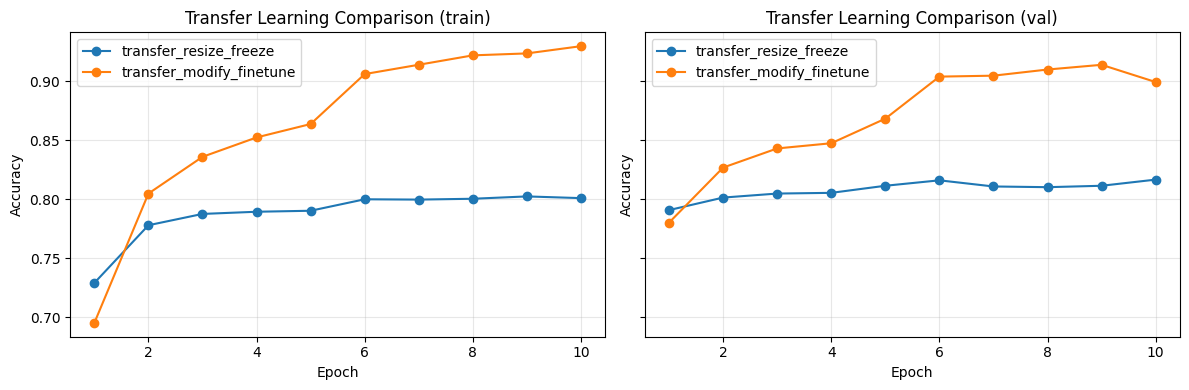

In [24]:
def plot_accuracy_curves(run_names, title):
    if runs_df.empty:
        print("No run CSVs found yet.")
        return

    subset = runs_df[runs_df["run_name"].isin(run_names) & runs_df["split"].isin(["train", "val"])]
    if subset.empty:
        print(f"No rows found for: {run_names}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for split, axis in zip(["train", "val"], axes):
        split_df = subset[subset["split"] == split]
        for run_name in run_names:
            run_df = split_df[split_df["run_name"] == run_name]
            axis.plot(run_df["epoch"], run_df["accuracy"], marker="o", label=run_name)
        axis.set_title(f"{title} ({split})")
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Accuracy")
        axis.grid(alpha=0.3)
        axis.legend()
    plt.tight_layout()


plot_accuracy_curves(
    ["transfer_resize_freeze", "transfer_modify_finetune"],
    "Transfer Learning Comparison",
)

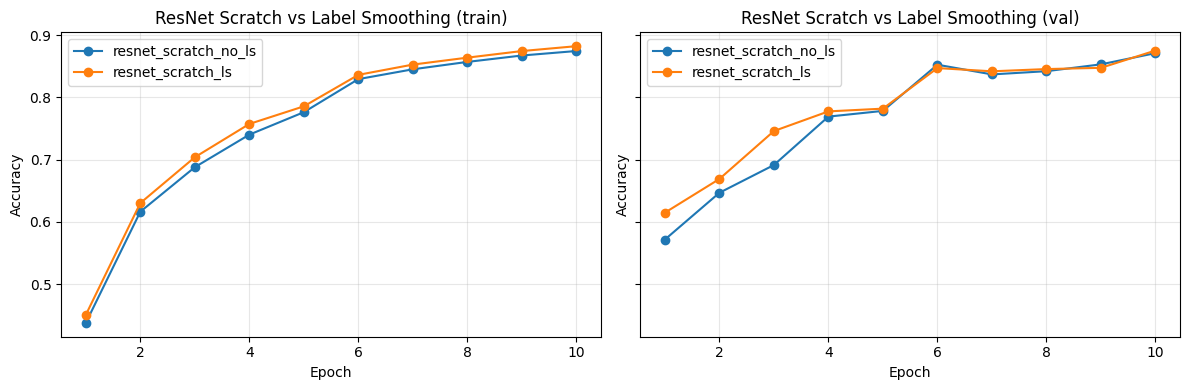

In [25]:
plot_accuracy_curves(
    ["resnet_scratch_no_ls", "resnet_scratch_ls"],
    "ResNet Scratch vs Label Smoothing",
)

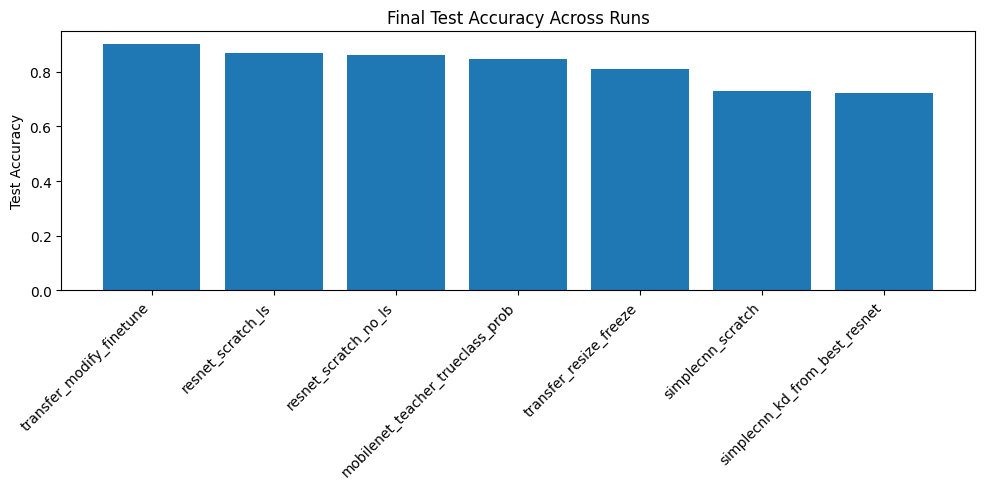

In [26]:
if not summary_df.empty:
    ordered = summary_df.sort_values("test_accuracy", ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(ordered["run_name"], ordered["test_accuracy"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Test Accuracy")
    plt.title("Final Test Accuracy Across Runs")
    plt.tight_layout()
else:
    print("No summary.csv found yet. Run the experiments first.")

In [27]:
if not summary_df.empty:
    compare_runs = summary_df[summary_df["run_name"].isin([
        "simplecnn_scratch",
        "simplecnn_kd_from_best_resnet",
        "mobilenet_teacher_trueclass_prob",
    ])].copy()
    if "teacher_run" in compare_runs.columns:
        compare_runs["teacher_run"] = compare_runs["teacher_run"].replace("", "-")
    display(compare_runs[["run_name", "teacher_run", "best_val_accuracy", "test_accuracy"]])
else:
    print("No summary.csv found yet. Run the experiments first.")

,run_name,teacher_run,best_val_accuracy,test_accuracy
2,simplecnn_scratch,-,0.7454,0.7314
5,simplecnn_kd_from_best_resnet,resnet_scratch_ls,0.7260,0.7213
6,mobilenet_teacher_trueclass_prob,resnet_scratch_ls,0.8518,0.8453


,arch_name,input_res,flops,macs,params
0,ResNet,3x32x32,1114449940,557224970,11173962
1,SimpleCNN,3x32x32,12553236,6276618,545098
2,MobileNetV2,3x32x32,192320532,96160266,2296922


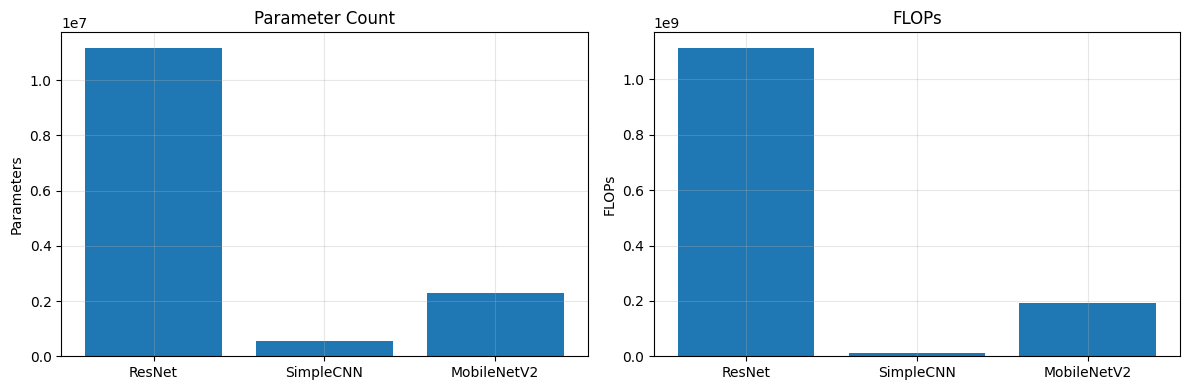

In [28]:
if not flops_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(flops_df["arch_name"], flops_df["params"])
    axes[0].set_title("Parameter Count")
    axes[0].set_ylabel("Parameters")
    axes[1].bar(flops_df["arch_name"], flops_df["flops"])
    axes[1].set_title("FLOPs")
    axes[1].set_ylabel("FLOPs")
    for axis in axes:
        axis.grid(alpha=0.3)
    plt.tight_layout()
    display(flops_df[["arch_name", "input_res", "flops", "macs", "params"]])
else:
    print("No flops_summary.csv found yet. Run the FLOPs step first.")
